In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Edit this only
SCENARIO_ROOT = Path("/home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm")

tile_row = "T336"
n_tag = "N_252"
seed_tag = "seed_1337"
repeat_tag = "repeat_0"

run_dir = SCENARIO_ROOT / tile_row / n_tag / seed_tag / repeat_tag

fold_files = [run_dir / f"fold_{k}_preds.json" for k in range(1, 6)]
print("Run dir:", run_dir)
print("Fold files:")
for f in fold_files:
    print("  ", f)

# ----------------------------------------------------------
# Load all folds, collect CDFs keyed by sid
# ----------------------------------------------------------
sid_to_true = {}
sid_to_pred = {}
bin_x_log10_ref = None

for fpath in fold_files:
    with open(fpath, "r") as fh:
        data = json.load(fh)

    bin_x_log10 = np.array(data["bin_x_log10"], dtype=float)
    if bin_x_log10_ref is None:
        bin_x_log10_ref = bin_x_log10
    else:
        if not np.allclose(bin_x_log10_ref, bin_x_log10, atol=1e-8):
            raise ValueError(f"bin_x_log10 mismatch in file {fpath}")

    for rec in data["predictions"]:
        sid = int(rec["sid"])
        pred_cdf = np.array(rec["pred_cdf"], dtype=float)   # in %
        true_cdf = np.array(rec["true_cdf"], dtype=float)   # in %

        if pred_cdf.shape != true_cdf.shape:
            raise ValueError(f"Shape mismatch for sid={sid} in {fpath}")

        if sid in sid_to_true:
            raise ValueError(f"Duplicate sid {sid} found in file {fpath}")

        sid_to_true[sid] = true_cdf
        sid_to_pred[sid] = pred_cdf

# ----------------------------------------------------------
# Build matrices
# rows    = true CDF of sid_i
# columns = predicted CDF of sid_j
# ----------------------------------------------------------
sids = sorted(sid_to_true.keys())
n = len(sids)
print(f"Found {n} samples")

true_mat = np.stack([sid_to_true[sid] for sid in sids], axis=0)   # (n, M), in %
pred_mat = np.stack([sid_to_pred[sid] for sid in sids], axis=0)   # (n, M), in %

M = true_mat.shape[1]
if pred_mat.shape[1] != M:
    raise ValueError("Pred and true CDFs have different length")

Run dir: /home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm/T336/N_252/seed_1337/repeat_0
Fold files:
   /home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm/T336/N_252/seed_1337/repeat_0/fold_1_preds.json
   /home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm/T336/N_252/seed_1337/repeat_0/fold_2_preds.json
   /home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm/T336/N_252/seed_1337/repeat_0/fold_3_preds.json
   /home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm/T336/N_252/seed_1337/repeat_0/fold_4_preds.json
   /home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs/loss_ablation_20251026-013209/cdf_cvm/T336/N_252/seed_1337/repeat_0/fold_5_preds.json
Found 316 samples


W1_matrix shape: (316, 316)
WMAE shape: (316, 316)
WMAE min/med/max: 0.5581490159016831 16.276456707743932 75.91830646547919
Coarsest sample sid: 320
Finest sample sid:   49
Best predicted sample sid: 220 WMAE = 0.5581490159016831
Worst predicted sample sid: 252 WMAE = 46.52302847138399
Finest sample sid: 289 D50 = 0.049999994920116315
Coarsest sample sid: 320 D50 = 25.316490596810944


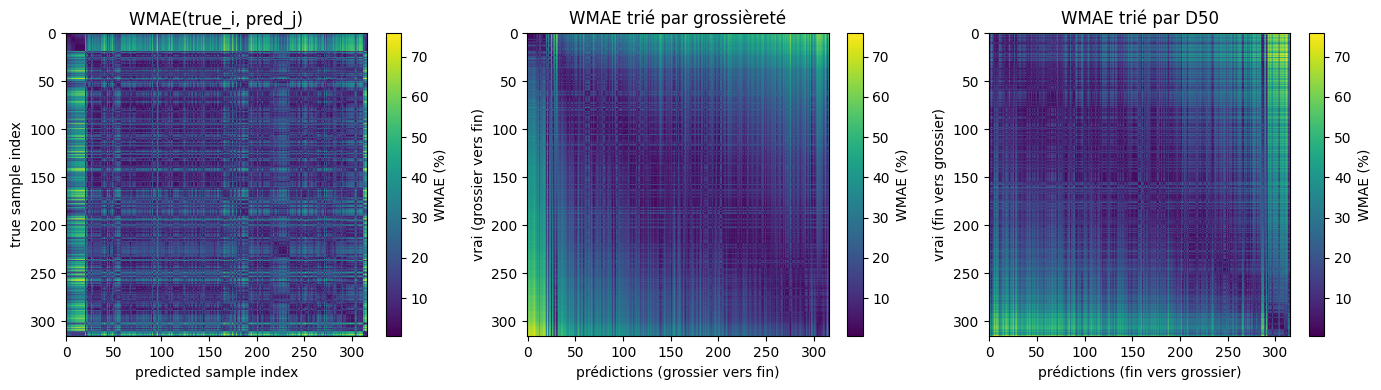

In [2]:
n, M = true_mat.shape 
assert pred_mat.shape == (n, M)

x_log = bin_x_log10_ref

dx = np.empty_like(x_log)
# Width of bins in middle
dx[1:-1] = 0.5 * np.abs(x_log[2:] - x_log[:-2])
# Width of bins on edges
dx[0] = np.abs(x_log[1] - x_log[0])
dx[-1] = np.abs(x_log[-1] - x_log[-2])

dx_row = dx.reshape(1, 1, -1)   # pour broadcast sur (n, n, M)
total_dx = dx.sum()

# List containing each sample's absolute difference of bins (%), before bin weighting.
diffs_percent = np.abs(true_mat[:, None, :] - pred_mat[None, :, :])  # (n, n, M)

# W1 en log10(mm).%
W1_matrix = (diffs_percent * dx_row).sum(axis=2)*100   # (n, n)

# WMAE en %
WMAE = W1_matrix / total_dx                        # (n, n)

print("W1_matrix shape:", W1_matrix.shape)
print("WMAE shape:", WMAE.shape)
print("WMAE min/med/max:", np.min(WMAE), np.median(WMAE), np.max(WMAE))

# ---------- Ordres pour différents tris ----------

x = bin_x_log10_ref

# Coarseness: aire au dessus de la CDF (plus grand = plus grossier)
coarseness = np.trapz(1.0 - true_mat, x, axis=1)

# Coarsest to finest
order_coarse = np.argsort(coarseness)[::-1]
WMAE_coarse_sorted = WMAE[order_coarse][:, order_coarse]
sids_coarse_sorted = [sids[i] for i in order_coarse]

print("Coarsest sample sid:", sids_coarse_sorted[0])
print("Finest sample sid:  ", sids_coarse_sorted[-1])

# Erreur par échantillon: diagonale de WMAE
diag_err = np.diag(WMAE)
order_err = np.argsort(diag_err)   # du meilleur au pire
WMAE_err_sorted = WMAE[order_err][:, order_err]
sids_err_sorted = [sids[i] for i in order_err]

print("Best predicted sample sid:", sids_err_sorted[0], "WMAE =", diag_err[order_err[0]])
print("Worst predicted sample sid:", sids_err_sorted[-1], "WMAE =", diag_err[order_err[-1]])

# D50 pour chaque échantillon
x_mm = 10.0 ** x
D50 = np.array([np.interp(0.5, cdf_i, x_mm) for cdf_i in true_mat])

order_D50 = np.argsort(D50)   # fin (petit D50) vers grossier (grand D50)
WMAE_D50_sorted = WMAE[order_D50][:, order_D50]
sids_D50_sorted = [sids[i] for i in order_D50]

print("Finest sample sid:", sids_D50_sorted[0], "D50 =", D50[order_D50[0]])
print("Coarsest sample sid:", sids_D50_sorted[-1], "D50 =", D50[order_D50[-1]])

# ---------- Figure en grille 2 x 2 ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# unpack
ax0, ax1, ax2 = axes

# 1. WMAE brut
im0 = ax0.imshow(WMAE, aspect="auto")
fig.colorbar(im0, ax=ax0, label="WMAE (%)")
ax0.set_title("WMAE(true_i, pred_j)")
ax0.set_xlabel("predicted sample index")
ax0.set_ylabel("true sample index")

# 2. Tri par grossièreté
im1 = ax1.imshow(WMAE_coarse_sorted, aspect="auto")
fig.colorbar(im1, ax=ax1, label="WMAE (%)")
ax1.set_title("WMAE trié par grossièreté")
ax1.set_xlabel("prédictions (grossier vers fin)")
ax1.set_ylabel("vrai (grossier vers fin)")

# 3. Tri par D50
im2 = ax2.imshow(WMAE_D50_sorted, aspect="auto")
fig.colorbar(im2, ax=ax2, label="WMAE (%)")
ax2.set_title("WMAE trié par D50")
ax2.set_xlabel("prédictions (fin vers grossier)")
ax2.set_ylabel("vrai (fin vers grossier)")

plt.tight_layout()
plt.show()


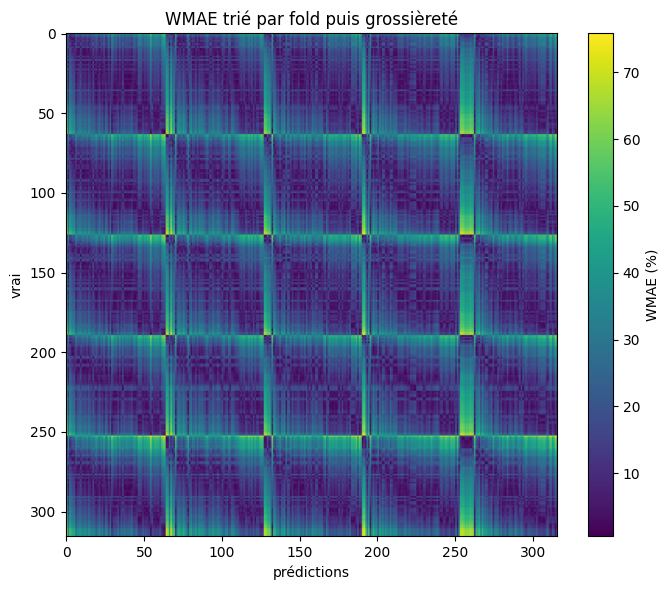

In [3]:
# Dimensions
n, M = true_mat.shape
assert pred_mat.shape == (n, M)

# ----------------------------------------
# Calcul du poids dx pour W1
# ----------------------------------------
x_log = bin_x_log10_ref

dx = np.empty_like(x_log)
dx[1:-1] = 0.5 * np.abs(x_log[2:] - x_log[:-2])
dx[0] = np.abs(x_log[1] - x_log[0])
dx[-1] = np.abs(x_log[-1] - x_log[-2])

dx_row = dx.reshape(1, 1, -1)
total_dx = dx.sum()

# ----------------------------------------
# WMAE entre tous les couples (true_i, pred_j)
# ----------------------------------------
diffs_percent = np.abs(true_mat[:, None, :] - pred_mat[None, :, :])
W1_matrix = (diffs_percent * dx_row).sum(axis=2) * 100.0
WMAE = W1_matrix / total_dx

# ----------------------------------------
# Coarseness pour trier grossier vers fin
# ----------------------------------------
true_cdf_norm = true_mat / 100.0
coarseness = np.trapz(1.0 - true_cdf_norm, x_log, axis=1)

# ----------------------------------------
# Mapping sid -> fold
# ----------------------------------------
sid_to_fold = {}
for fold_idx, fpath in enumerate(fold_files, start=1):
    with open(fpath, "r") as fh:
        data_fold = json.load(fh)
    for rec in data_fold["predictions"]:
        sid = int(rec["sid"])
        sid_to_fold[sid] = fold_idx

fold_ids = np.array([sid_to_fold[sid] for sid in sids], dtype=int)

# ----------------------------------------
# Tri combiné: fold puis grossièreté
# ----------------------------------------
order_fold_coarse = np.lexsort((
    -coarseness,   # secondaire: grossier vers fin
    fold_ids       # primaire: fold croissant
))

WMAE_fold_coarse_sorted = WMAE[order_fold_coarse][:, order_fold_coarse]

# ----------------------------------------
# Affichage
# ----------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

im = ax.imshow(WMAE_fold_coarse_sorted, aspect="auto")
fig.colorbar(im, ax=ax, label="WMAE (%)")

ax.set_title("WMAE trié par fold puis grossièreté")
ax.set_xlabel("prédictions")
ax.set_ylabel("vrai")

plt.tight_layout()
plt.show()


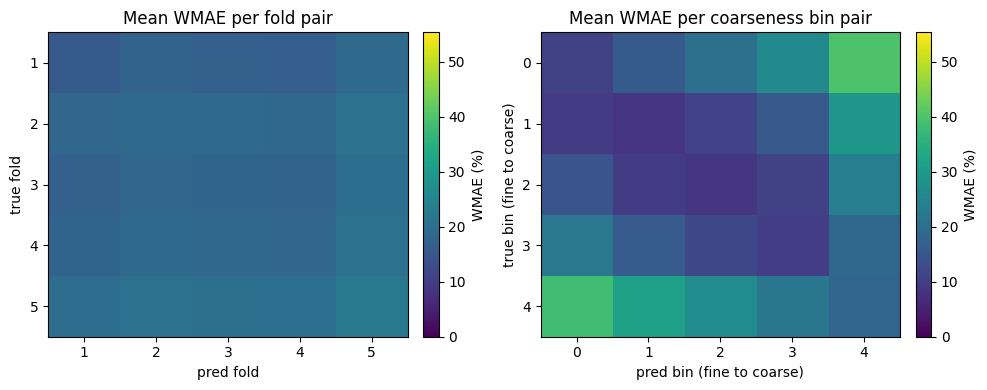

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# ---------------------------------------------------
# Assumes these already exist:
#   WMAE          (n x n)
#   true_mat      (n x M), in %
#   pred_mat      (n x M), in %
#   sids          list or array of length n
#   sid_to_fold   dict sid -> fold_id
#   bin_x_log10_ref
# ---------------------------------------------------

n, M = true_mat.shape
x_log = bin_x_log10_ref

# 1) Fold to fold mean WMAE
fold_ids = np.array([sid_to_fold[sid] for sid in sids], dtype=int)
unique_folds = np.unique(fold_ids)
F = len(unique_folds)

W_fold = np.zeros((F, F), dtype=float)
for i_f, f_true in enumerate(unique_folds):
    idx_true = np.where(fold_ids == f_true)[0]
    for j_f, f_pred in enumerate(unique_folds):
        idx_pred = np.where(fold_ids == f_pred)[0]
        block = WMAE[np.ix_(idx_true, idx_pred)]
        W_fold[i_f, j_f] = block.mean() if block.size > 0 else np.nan

# 2) Coarseness bins and mean WMAE per bin pair
true_cdf_norm = true_mat / 100.0
coarseness = np.trapz(1.0 - true_cdf_norm, x_log, axis=1)

k_bins = 5
q_edges = np.quantile(coarseness, np.linspace(0.0, 1.0, k_bins + 1))
q_edges[0] = coarseness.min()
q_edges[-1] = coarseness.max()

bin_ids = np.digitize(coarseness, q_edges, right=True) - 1
bin_ids = np.clip(bin_ids, 0, k_bins - 1)

W_coarse_bins = np.zeros((k_bins, k_bins), dtype=float)
for i_b in range(k_bins):
    idx_i = np.where(bin_ids == i_b)[0]
    for j_b in range(k_bins):
        idx_j = np.where(bin_ids == j_b)[0]
        block = WMAE[np.ix_(idx_i, idx_j)]
        W_coarse_bins[i_b, j_b] = block.mean() if block.size > 0 else np.nan

# ---------------------------------------------------
# Plot the three matrices
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wmin = 0.0
wmax = np.percentile(WMAE, 99)

# 1. Fold to fold mean WMAE
ax = axes[0]
im_fold = ax.imshow(W_fold, aspect="auto", vmin=wmin, vmax=wmax)
ax.set_title("Mean WMAE per fold pair")
ax.set_xlabel("pred fold")
ax.set_ylabel("true fold")
ax.set_xticks(np.arange(F))
ax.set_yticks(np.arange(F))
ax.set_xticklabels(unique_folds)
ax.set_yticklabels(unique_folds)
fig.colorbar(im_fold, ax=ax, fraction=0.046, pad=0.04, label="WMAE (%)")

# 2. Coarseness bin to bin mean WMAE
ax = axes[1]
im_coarse = ax.imshow(W_coarse_bins, aspect="auto", vmin=wmin, vmax=wmax)
ax.set_title("Mean WMAE per coarseness bin pair")
ax.set_xlabel("pred bin (fine to coarse)")
ax.set_ylabel("true bin (fine to coarse)")
ax.set_xticks(np.arange(k_bins))
ax.set_yticks(np.arange(k_bins))
fig.colorbar(im_coarse, ax=ax, fraction=0.046, pad=0.04, label="WMAE (%)")

plt.tight_layout()
plt.show()


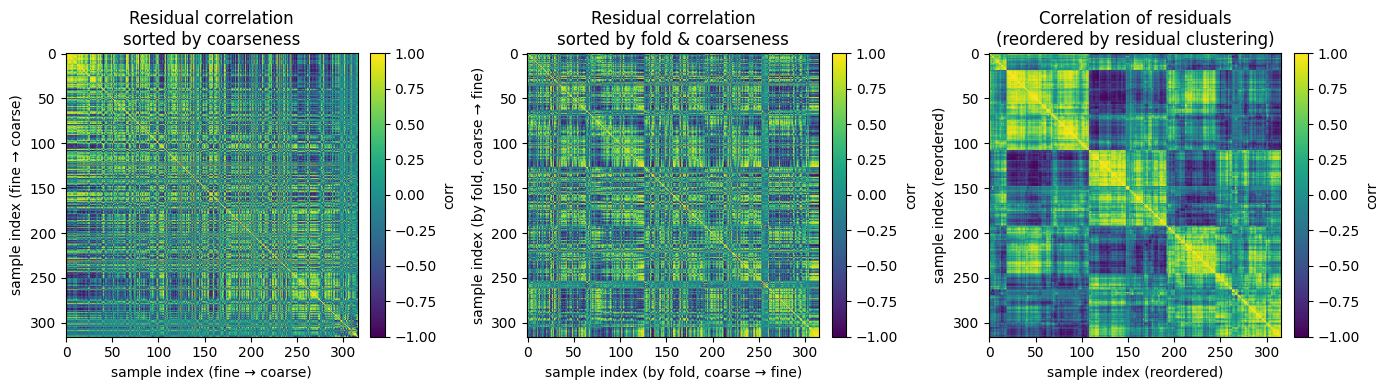

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform, pdist

# ---------------------------------------------------
# Assumes these already exist:
#   true_mat      (n x M), in %
#   pred_mat      (n x M), in %
#   sids          list or array of length n
#   sid_to_fold   dict sid -> fold_id
#   bin_x_log10_ref
# ---------------------------------------------------

n, M = true_mat.shape
x_log = bin_x_log10_ref

# 1) Coarseness of each sample (for sorting)
true_cdf_norm = true_mat / 100.0
coarseness = np.trapz(1.0 - true_cdf_norm, x_log, axis=1)

# Fold ids
fold_ids = np.array([sid_to_fold[sid] for sid in sids], dtype=int)

# 2) Residual correlation between samples
R = pred_mat - true_mat
R_centered = R - R.mean(axis=1, keepdims=True)
cov = R_centered @ R_centered.T / max(M - 1, 1)

std = np.sqrt(np.diag(cov))
denom = std[:, None] * std[None, :] + 1e-8
corr = cov / denom   # (n, n)

# 3) Four different orderings

# a) Sorted by coarseness (fine -> coarse)
order_coarse = np.argsort(coarseness)
corr_coarse = corr[order_coarse][:, order_coarse]

# b) Sorted by fold then coarseness
order_fold_coarse = np.lexsort((-coarseness, fold_ids))
corr_fold_coarse = corr[order_fold_coarse][:, order_fold_coarse]

# c) Reordered by clustering on residual correlation
dist = 1.0 - corr
dist = np.clip(dist, 0.0, None)
dist = 0.5 * (dist + dist.T)
np.fill_diagonal(dist, 0.0)

dist_vec = squareform(dist)
Z = linkage(dist_vec, method="ward")
order_hc = leaves_list(Z)
corr_cluster = corr[order_hc][:, order_hc]
# ---------------------------------------------------
# Plot the four correlation matrices
# ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vmin, vmax = -1.0, 1.0

# 1. Residuals sorted by coarseness
ax = axes[0]
im0 = ax.imshow(corr_coarse, aspect="auto", vmin=vmin, vmax=vmax)
ax.set_title("Residual correlation\nsorted by coarseness")
ax.set_xlabel("sample index (fine → coarse)")
ax.set_ylabel("sample index (fine → coarse)")
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04, label="corr")

# 2. Residuals sorted by fold then coarseness
ax = axes[1]
im1 = ax.imshow(corr_fold_coarse, aspect="auto", vmin=vmin, vmax=vmax)
ax.set_title("Residual correlation\nsorted by fold & coarseness")
ax.set_xlabel("sample index (by fold, coarse → fine)")
ax.set_ylabel("sample index (by fold, coarse → fine)")
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04, label="corr")

# 3. Residuals reordered by clustering on residuals
ax = axes[2]
im2 = ax.imshow(corr_cluster, aspect="auto", vmin=vmin, vmax=vmax)
ax.set_title("Correlation of residuals\n(reordered by residual clustering)")
ax.set_xlabel("sample index (reordered)")
ax.set_ylabel("sample index (reordered)")
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label="corr")

plt.tight_layout()
plt.show()


Cluster level summary:
         n_samples  wmae_median   wmae_p90  coarseness_median  D50_median
cluster                                                                  
1               19     4.555462  10.877944           1.583205    2.479736
2               48     7.533526  15.038836           0.548973    0.099007
3               41     4.677567  15.619974           0.630953    0.122823
4               84     5.183787  15.790884           1.250553    0.918341
5               53     4.585267   9.346424           0.765776    0.187184
6               71     3.995215   6.193047           1.014609    0.421388

Cluster vs fold counts:
fold      1   2   3   4   5
cluster                    
1         4   2   2   7   4
2        10  12  11  11   4
3         4   2  11  11  13
4        13  12  15  15  29
5        14  15  10  12   2
6        19  20  14   7  11

Cluster vs coarseness quintiles:
coarseness   0   1   2   3   4
cluster                       
1            0   1   3   3  12
2        

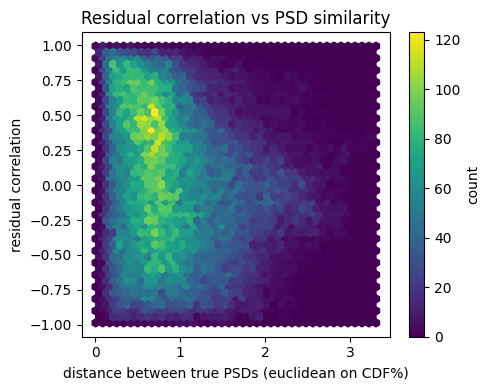

Pearson corr(dist_PSD, resid_corr) = -0.173


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, pdist

# Assumes:
# true_mat, pred_mat   (n, M) in %
# bin_x_log10_ref
# sids                 list of length n
# sid_to_fold          dict sid -> fold id
# WMAE                 (n, n) pairwise WMAE matrix

n, M = true_mat.shape
x_log = bin_x_log10_ref
x_mm = 10.0 ** x_log

# ---------- Residuals and correlation between samples ----------
R = pred_mat - true_mat
R_centered = R - R.mean(axis=1, keepdims=True)
cov = R_centered @ R_centered.T / max(M - 1, 1)

std = np.sqrt(np.diag(cov))
denom = std[:, None] * std[None, :] + 1e-8
corr = cov / denom                      # (n, n)

# ---------- Basic per sample features ----------
true_cdf_norm = true_mat
coarseness = np.trapz(1.0 - true_cdf_norm, x_log, axis=1)

x_mm = 10.0 ** x_log
D50 = np.array([np.interp(0.5, cdf_i, x_mm) for cdf_i in true_cdf_norm])

fold_ids = np.array([sid_to_fold[sid] for sid in sids], dtype=int)
diag_wmae = np.diag(WMAE)

# ============================================================
# 1) Find residual-correlation clusters and relate to features
# ============================================================

# Distance for clustering on residual correlation
dist_resid = 1.0 - corr
dist_resid = np.clip(dist_resid, 0.0, None)
dist_resid = 0.5 * (dist_resid + dist_resid.T)
np.fill_diagonal(dist_resid, 0.0)

dist_vec = squareform(dist_resid)
Z = linkage(dist_vec, method="ward")

K = 6  # number of clusters, tweak if needed
cluster_ids = fcluster(Z, K, criterion="maxclust")

df_samples = pd.DataFrame({
    "sid": sids,
    "cluster": cluster_ids,
    "fold": fold_ids,
    "coarseness": coarseness,
    "D50": D50,
    "diag_wmae": diag_wmae,
})

print("Cluster level summary:")
cluster_summary = (
    df_samples
    .groupby("cluster")
    .agg(
        n_samples=("sid", "count"),
        wmae_median=("diag_wmae", "median"),
        wmae_p90=("diag_wmae", lambda x: np.percentile(x, 90)),
        coarseness_median=("coarseness", "median"),
        D50_median=("D50", "median"),
    )
    .sort_index()
)
print(cluster_summary)

print("\nCluster vs fold counts:")
print(pd.crosstab(df_samples["cluster"], df_samples["fold"]))

print("\nCluster vs coarseness quintiles:")
coarse_q = pd.qcut(df_samples["coarseness"], 5, labels=False, duplicates="drop")
print(pd.crosstab(df_samples["cluster"], coarse_q))

# ============================================================
# 2) Relation between PSD similarity and residual correlation
# ============================================================

# Pairwise distance between true CDF shapes (in %)
# You can replace "euclidean" by something else if you want
dist_psd_vec = pdist(true_cdf_norm, metric="euclidean")  # (n*(n-1)/2,)

# Corresponding residual correlations (upper triangle)
iu = np.triu_indices(n, k=1)
corr_vec = corr[iu]

# Plot: PSD distance vs residual correlation
plt.figure(figsize=(5, 4))
plt.hexbin(dist_psd_vec, corr_vec, gridsize=40, cmap="viridis")
plt.colorbar(label="count")
plt.xlabel("distance between true PSDs (euclidean on CDF%)")
plt.ylabel("residual correlation")
plt.title("Residual correlation vs PSD similarity")
plt.tight_layout()
plt.show()

# Also print correlation between these two quantities
rho = np.corrcoef(dist_psd_vec, corr_vec)[0, 1]
print(f"Pearson corr(dist_PSD, resid_corr) = {rho:.3f}")


Coarseness family summary:
        n_samples  wmae_median   wmae_p90  coarseness_min  coarseness_median  \
family                                                                         
0              22    10.638009  20.359344        3.172086           3.173407   
1              21     6.034090  11.450186        3.174906           3.175346   
2              21     4.545179   9.937592        3.176055           3.176649   
3              21     4.107349   7.688900        3.177540           3.177992   
4              21     4.052624   7.018936        3.178433           3.179176   
5              21     5.290517  10.266627        3.179588           3.179883   
6              21     4.729681   7.377907        3.180131           3.180683   
7              21     5.109297  10.468241        3.181308           3.181529   
8              21     5.126630   8.564468        3.181807           3.182203   
9              21     3.435735   9.972157        3.182600           3.183336   
10           

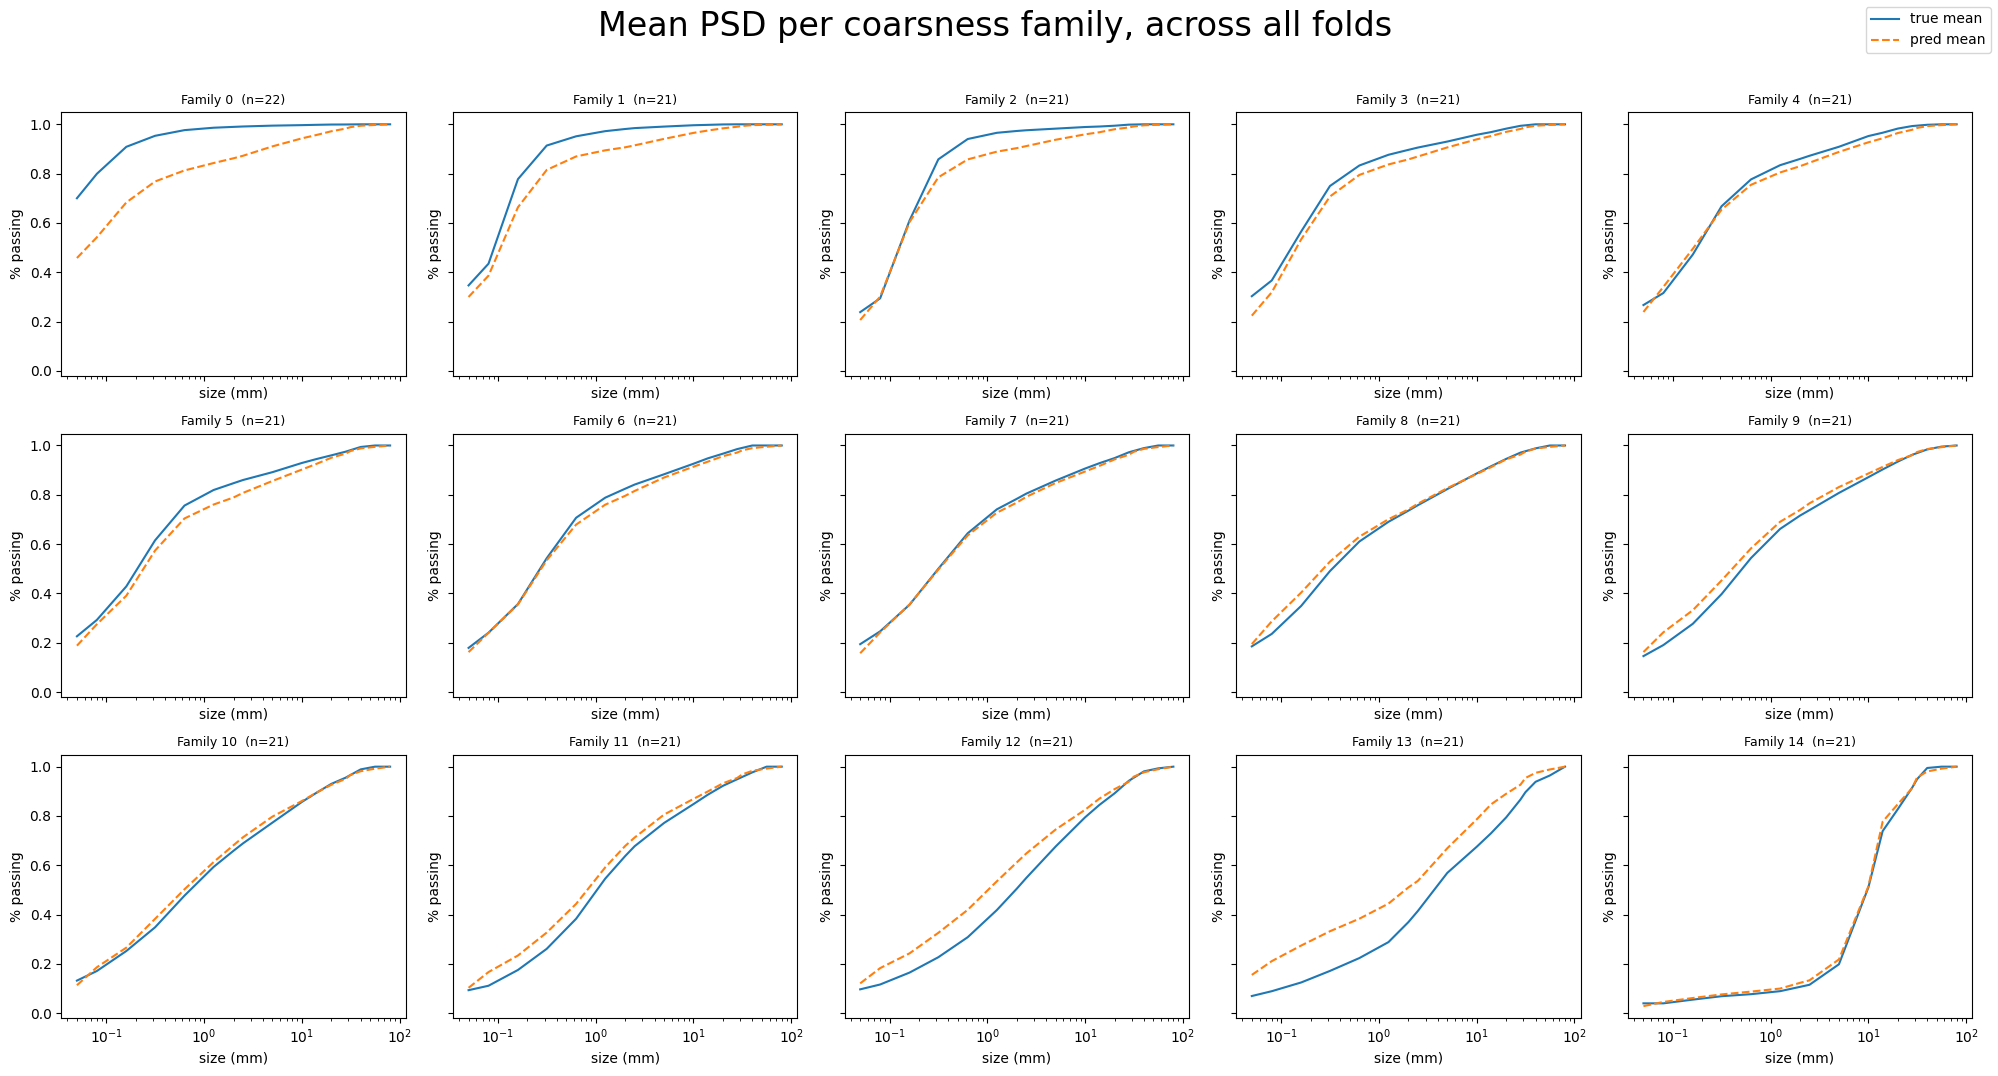

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Coarseness per sample and binning into families
# ---------------------------------------------------
x_log = bin_x_log10_ref
x_mm = 10.0 ** x_log

true_cdf_norm = true_mat / 100.0
coarseness = np.trapz(1.0 - true_cdf_norm, x_log, axis=1)  # larger = coarser

diag_wmae = np.diag(WMAE)

# Number of coarseness families
K_COARSE = 15  # change if you want fewer or more families

# Quantile based edges
q_edges = np.quantile(coarseness, np.linspace(0.0, 1.0, K_COARSE + 1))

# Make sure edges cover the full range
q_edges[0] = coarseness.min()
q_edges[-1] = coarseness.max()

# Assign each sample to a coarseness family id in [0, K_COARSE-1]
family_ids = np.digitize(coarseness, q_edges, right=True) - 1
family_ids = np.clip(family_ids, 0, K_COARSE - 1)

df_coarse = pd.DataFrame({
    "sid": sids,
    "family": family_ids,
    "diag_wmae": diag_wmae,
    "coarseness": coarseness,
    "D50": D50,
})

# ---------------------------------------------------
# 2. Summary table per coarseness family
# ---------------------------------------------------
summary_coarse = (
    df_coarse
    .groupby("family")
    .agg(
        n_samples=("sid", "count"),
        wmae_median=("diag_wmae", "median"),
        wmae_p90=("diag_wmae", lambda x: np.percentile(x, 90)),
        coarseness_min=("coarseness", "min"),
        coarseness_median=("coarseness", "median"),
        coarseness_max=("coarseness", "max"),
        D50_median=("D50", "median"),
    )
    .sort_index()
)

print("Coarseness family summary:")
print(summary_coarse)

# ---------------------------------------------------
# 3. Plot mean true and predicted PSD per family
# ---------------------------------------------------
n_cols = min(5, K_COARSE)
n_rows = int(np.ceil(K_COARSE / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

for fam in range(K_COARSE):
    ax = axes[fam]
    idx = df_coarse["family"] == fam
    if not np.any(idx):
        ax.set_visible(False)
        continue

    mean_true = true_mat[idx].mean(axis=0)
    mean_pred = pred_mat[idx].mean(axis=0)

    ax.plot(x_mm, mean_true, label="true mean")
    ax.plot(x_mm, mean_pred, linestyle="--", label="pred mean")

    ax.set_xscale("log")
    ax.set_title(f"Family {fam}  (n={idx.sum()})", fontsize=9)
    ax.set_xlabel("size (mm)")
    ax.set_ylabel("% passing")

# Hide unused axes if K_COARSE < n_rows * n_cols
for j in range(K_COARSE, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle("Mean PSD per coarsness family, across all folds", fontsize=24, y=1.02)

plt.tight_layout()
plt.show()


Counts per (family, fold):
fold     1   2   3   4   5
family                    
0       13  13  12  13  13
1       14   8  13  16  12
2       16  11  16  10  10
3       12  16  14  11  10
4        9  15   8  13  18

Summary per family and fold:
             n_samples  wmae_median   wmae_p90  coarseness_median  D50_median
family fold                                                                  
0      1            13     5.186970   8.745101           3.175463    0.083941
       2            13     9.937592  14.510713           3.175572    0.050000
       3            12     5.332559  15.861626           3.176060    0.117658
       4            13     5.481839  20.498796           3.175197    0.084088
       5            13     5.696584  19.893280           3.174542    0.050000
1      1            14     4.410677   7.487911           3.179291    0.170513
       2             8     5.650336  12.202165           3.179163    0.150869
       3            13     4.052624   7.380205      

/tmp/ipykernel_1594081/1898282459.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_folds)


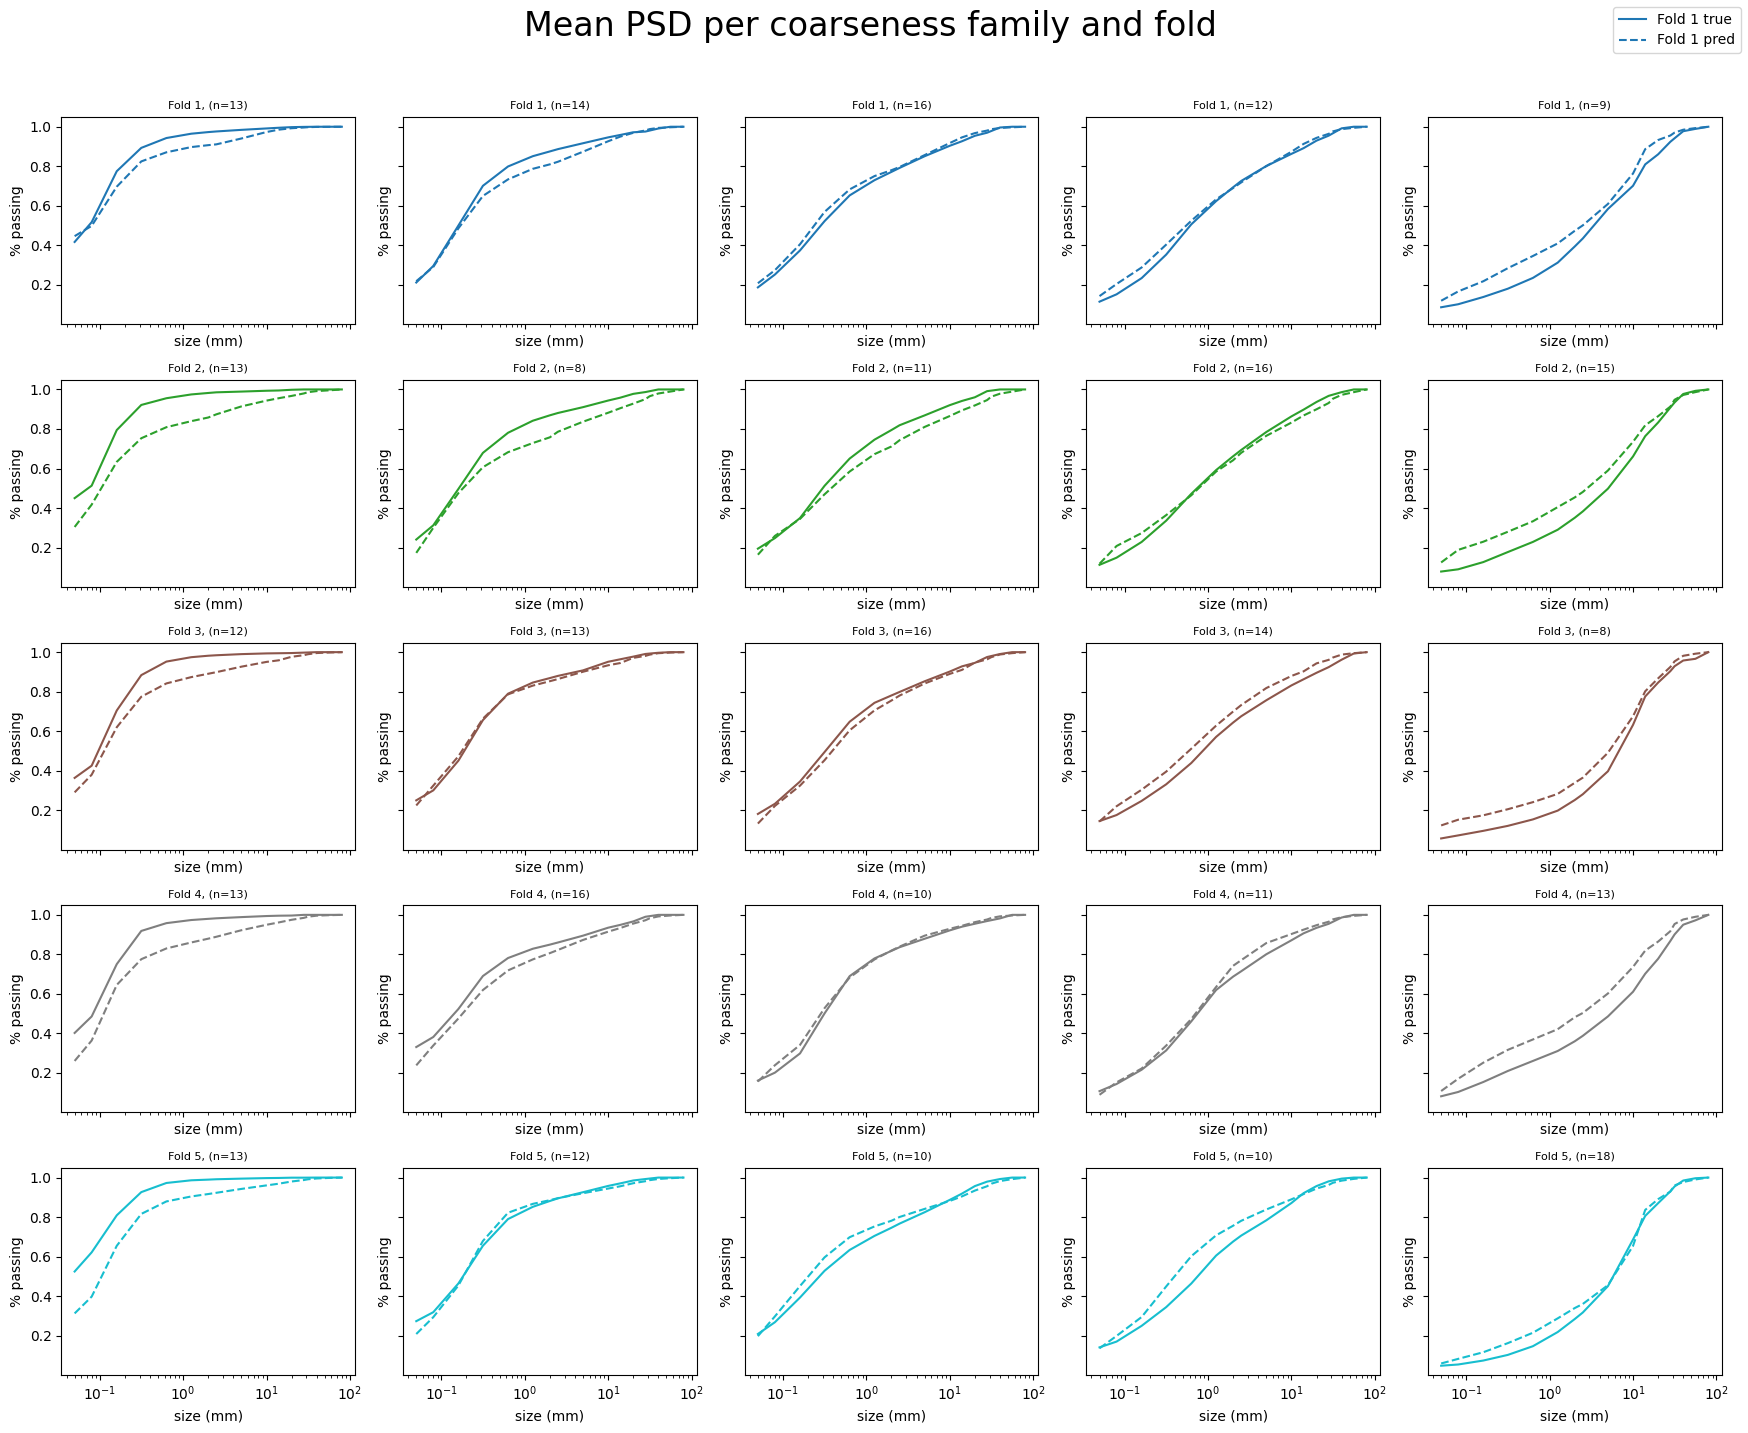

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Coarseness per sample and binning into families
# ---------------------------------------------------
x_log = bin_x_log10_ref
x_mm = 10.0 ** x_log

true_cdf_norm = true_mat / 100.0
coarseness = np.trapz(1.0 - true_cdf_norm, x_log, axis=1)  # larger = coarser

diag_wmae = np.diag(WMAE)

# Number of coarseness families
K_COARSE = 5

# Quantile based edges (global, all samples)
q_edges = np.quantile(coarseness, np.linspace(0.0, 1.0, K_COARSE + 1))
q_edges[0] = coarseness.min()
q_edges[-1] = coarseness.max()

# Assign each sample to a coarseness family id in [0, K_COARSE-1]
family_ids = np.digitize(coarseness, q_edges, right=True) - 1
family_ids = np.clip(family_ids, 0, K_COARSE - 1)

# Fold ids from sid_to_fold
fold_ids = np.array([sid_to_fold[sid] for sid in sids], dtype=int)

df_coarse = pd.DataFrame({
    "sid": sids,
    "fold": fold_ids,
    "family": family_ids,
    "diag_wmae": diag_wmae,
    "coarseness": coarseness,
    "D50": D50,
})

# ---------------------------------------------------
# 2. Summary per coarseness family and per fold
# ---------------------------------------------------
print("Counts per (family, fold):")
counts = pd.crosstab(df_coarse["family"], df_coarse["fold"])
print(counts)

summary_coarse_fold = (
    df_coarse
    .groupby(["family", "fold"])
    .agg(
        n_samples=("sid", "count"),
        wmae_median=("diag_wmae", "median"),
        wmae_p90=("diag_wmae", lambda x: np.percentile(x, 90)),
        coarseness_median=("coarseness", "median"),
        D50_median=("D50", "median"),
    )
    .sort_index()
)

print("\nSummary per family and fold:")
print(summary_coarse_fold)

# ---------------------------------------------------
# 3. Single grid: rows = folds, cols = families
#    true/pred color depends on fold
# ---------------------------------------------------
unique_folds = sorted(df_coarse["fold"].unique())
n_folds = len(unique_folds)

n_rows = n_folds
n_cols = K_COARSE

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.5 * n_cols, 2.8 * n_rows),
    sharex=True,
    sharey=True,
)

axes = np.array(axes)

# Color per fold
cmap = plt.cm.get_cmap("tab10", n_folds)
fold_to_color = {fold: cmap(i) for i, fold in enumerate(unique_folds)}

for i, fold in enumerate(unique_folds):
    color = fold_to_color[fold]

    for fam in range(K_COARSE):
        ax = axes[i, fam]

        idx_global = (
            (df_coarse["fold"].to_numpy() == fold) &
            (df_coarse["family"].to_numpy() == fam)
        )

        if not np.any(idx_global):
            ax.set_visible(False)
            continue

        mean_true = true_mat[idx_global].mean(axis=0)
        mean_pred = pred_mat[idx_global].mean(axis=0)

        # same color for this fold, solid vs dashed for true/pred
        ax.plot(x_mm, mean_true, color=color, label=f"Fold {fold} true")
        ax.plot(x_mm, mean_pred, color=color, linestyle="--", label=f"Fold {fold} pred")

        ax.set_xscale("log")
        ax.set_xlabel("size (mm)")
        ax.set_ylabel("% passing")

        n_here = idx_global.sum()
        ax.set_title(f"Fold {fold}, (n={n_here})", fontsize=8)

# hide any accidentally unused axes if shapes change
for i in range(n_rows):
    for j in range(n_cols):
        if i >= n_folds or j >= K_COARSE:
            axes[i, j].set_visible(False)

# global legend from first visible axis
first_ax = None
for ax in axes.ravel():
    if ax.get_visible():
        first_ax = ax
        break

if first_ax is not None:
    handles, labels = first_ax.get_legend_handles_labels()
    # remove duplicates while preserving order
    seen = set()
    uniq_handles = []
    uniq_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            uniq_handles.append(h)
            uniq_labels.append(l)
    fig.legend(uniq_handles, uniq_labels, loc="upper right")

fig.suptitle("Mean PSD per coarseness family and fold", fontsize=24, y=1.02, )
plt.tight_layout()
plt.show()


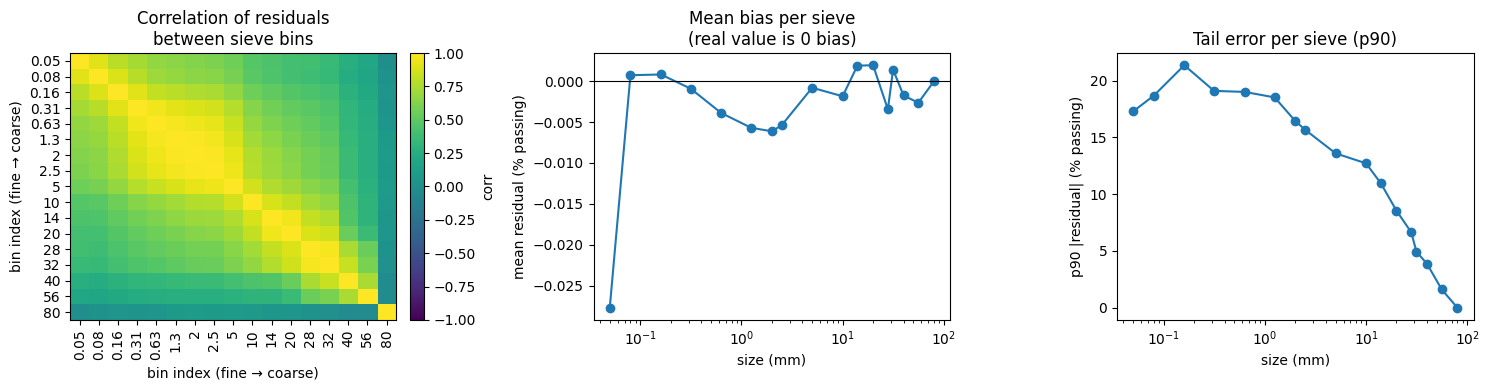

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes: true_mat, pred_mat, bin_x_log10_ref already defined
x_log = bin_x_log10_ref
x_mm = 10.0 ** x_log
n, M = true_mat.shape

# Residuals in % passing
R = pred_mat - true_mat          # (n, M)

# ------------------------------
# 1) Bin–bin correlation matrix
# ------------------------------
R_centered = R - R.mean(axis=0, keepdims=True)
corr_bins = np.corrcoef(R_centered, rowvar=False)   # (M, M)

# ------------------------------
# 2) Bias and tail error per bin
# ------------------------------
bias = R.mean(axis=0)                                # mean signed error per bin
p90_abs = np.percentile(np.abs(R), 90, axis=0)*100       # 90th percentile abs error

# ------------------------------
# 3) Single grid: 1 row, 3 columns
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Correlation heatmap
ax = axes[0]
im = ax.imshow(corr_bins, aspect="auto", vmin=-1.0, vmax=1.0)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="corr")
ax.set_title("Correlation of residuals\nbetween sieve bins")
ax.set_xlabel("bin index (fine → coarse)")
ax.set_ylabel("bin index (fine → coarse)")
ax.set_xticks(np.arange(M))
ax.set_yticks(np.arange(M))
ax.set_xticklabels([f"{d:.2g}" for d in x_mm], rotation=90)
ax.set_yticklabels([f"{d:.2g}" for d in x_mm])

# (b) Mean bias
ax = axes[1]
ax.plot(x_mm, bias, marker="o")
ax.set_xscale("log")
ax.axhline(0.0, color="k", linewidth=0.8)
ax.set_xlabel("size (mm)")
ax.set_ylabel("mean residual (% passing)")
ax.set_title("Mean bias per sieve\n(real value is 0 bias)")

# (c) Tail error (p90 of |residual|)
ax = axes[2]
ax.plot(x_mm, p90_abs, marker="o")
ax.set_xscale("log")
ax.set_xlabel("size (mm)")
ax.set_ylabel("p90 |residual| (% passing)")
ax.set_title("Tail error per sieve (p90)")

plt.tight_layout()
plt.show()
